In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [2]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
]

In [3]:
#RUN = ["1","2","3","4b","4c","4d","5"]
RUN = ["3"]

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=True,
    load_crt_vars=False,
    enable_cache=False,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'ccnc', 'nu_pdg'}
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/bnb_beam_off_peleeTuple_uboone_v08_00_00_70_run3.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nu.root


../../data_loading.py:857: RuntimeWarning: invalid value encountered in true_divide
  df["proton_pz"] = np.where((mc_E_prot > 0), mc_pz_prot / mc_p_prot, np.nan)


Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_nue.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only
/exp/uboone/data/users/cthorpe/PELEE_2023_Samples/run3/nuepresel/overlay_peleeTuple_uboone_v08_00_00_70_run3_dirt.root
Calc true TKI variables for leading proton only
Calc true GKI variables for leading proton only
Calc reco TKI variables for leading proton only
Calc reco GKI variables for leading proton only


In [4]:
run_combo = "Run"
for run in RUN:
    run_combo += run

In [5]:
from microfit import selections as sel

selection = "None"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']}" #" and {sel.selection_categories[selection]['query']}"
#sel_title = f"{sel.selection_categories[selection]['title']}"

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
sel_mc = all_mc.query(query, engine='python')
is_sig = sel_mc['category_1e1p'] == 12
sel_sig = sel_mc.loc[is_sig]
sel_bkg = sel_mc.loc[~is_sig]


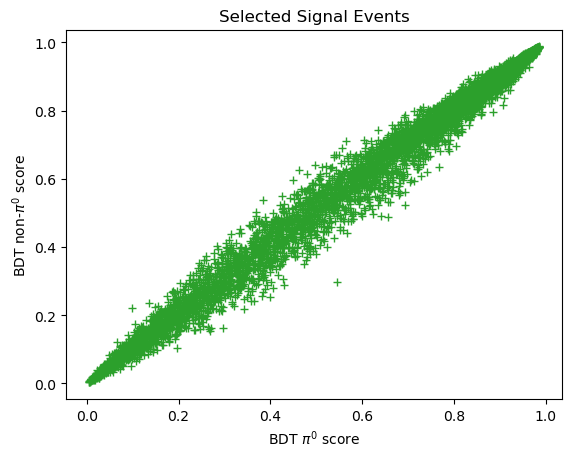

<Figure size 640x480 with 0 Axes>

In [6]:
# Selected signal - pi0 & non-pi0

plt.plot(sel_sig["pi0_score"], sel_sig["nonpi0_score"], "+", color="tab:green")
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('BDT non-$\\pi^{0}$ score')  
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

OSError: [Errno 127] Key has expired: '/nashome/m/mmoudgal/.ipython'

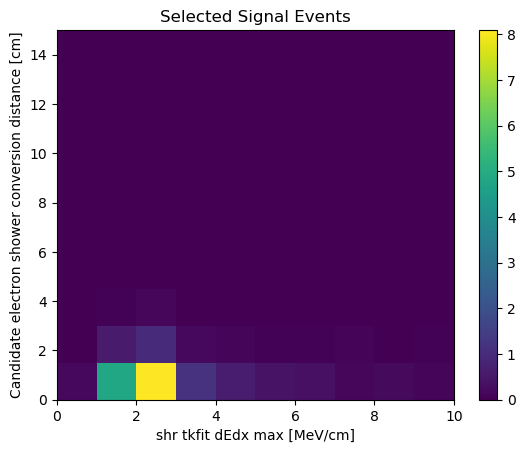

In [13]:
# Selected signal - pi0 & 0p

plt.plot(sel_sig["pi0_score"], sel_sig["bkg_score"], "+", color="tab:green")
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')  
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

OSError: [Errno 127] Key has expired: '/nashome/m/mmoudgal/.ipython'

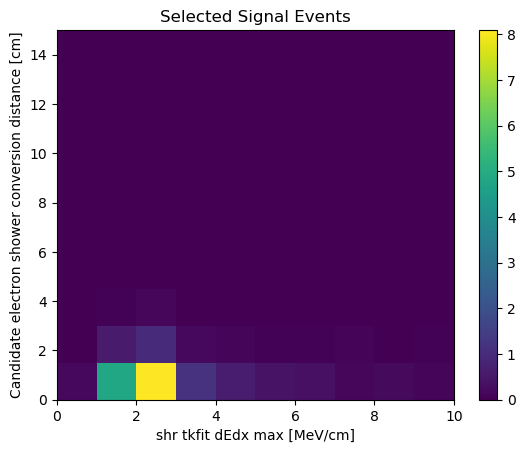

In [13]:
# Selected signal - nonpi0 & 0p

plt.plot(sel_sig["nonpi0_score"], sel_sig["bkg_score"], "+", color="tab:green")
plt.xlabel('BDT non-$\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

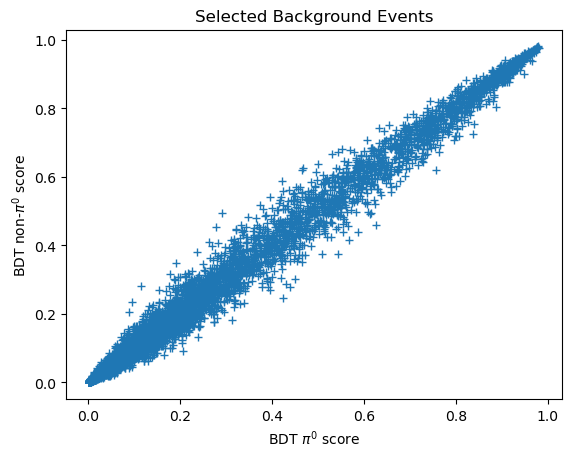

<Figure size 640x480 with 0 Axes>

In [7]:
# Selected background - pi0 & non-pi0

plt.plot(sel_bkg["pi0_score"], sel_bkg["nonpi0_score"], "+")
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('BDT non-$\\pi^{0}$ score')
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - pi0 & 0p

plt.plot(sel_bkg["pi0_score"], sel_bkg["bkg_score"], "+")
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - nonpi0 & 0p

plt.plot(sel_bkg["nonpi0_score"], sel_bkg["bkg_score"], "+")
plt.xlabel('BDT non-$\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_scatter_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()